# Phase 2 - Separating Carbon Tax from ETS

Phase 1 used `post_carbon_tax`, which conflates national carbon taxes with EU ETS adoption: EU countries switch on in 2005 (the ETS launch) whether or not they have a national tax (e.g. Germany has no national tax in range but `post_carbon_tax`=1 from 2005). Here we re-estimate using the clean `has_tax` and `has_ets` indicators - both with country + year fixed effects and clustered SEs - to recover a genuine carbon-tax effect distinct from the ETS effect. See `docs/FUTURE_DATA_EXPANSION.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv("../data/cleaned/final_analysis_data.csv")
y = 'co2_per_capita_future_trend'
controls = 'log_gdp + log_population + trade_openness + natural_resource_rents_per_gdp + fossil_pct_filled'
need = [y, 'has_tax', 'has_ets', 'post_carbon_tax', 'log_gdp', 'log_population',
        'trade_openness', 'natural_resource_rents_per_gdp', 'fossil_pct_filled']
d = df.dropna(subset=need).copy()

# 4-cell policy classification + raw outcome means (descriptive, unadjusted)
d['policy'] = np.select(
    [(d.has_tax == 0) & (d.has_ets == 0), (d.has_tax == 1) & (d.has_ets == 0),
     (d.has_tax == 0) & (d.has_ets == 1), (d.has_tax == 1) & (d.has_ets == 1)],
    ['none', 'tax only', 'ETS only', 'both'], default='none')
print(d.groupby('policy')[y].agg(['mean', 'count']).round(3))

           mean  count
policy                
ETS only -0.184    293
both     -0.220    117
none     -0.000   3029
tax only -0.115     94


## 1. Conflated vs clean treatments

The same DiD spec (country + year FE, clustered SEs), changing only the treatment variable.

In [2]:
fe = f"+ {controls} + C(year) + C(country)"

def fit(formula):
    return smf.ols(formula, data=d).fit(cov_type='cluster', cov_kwds={'groups': d['country']})

rows = []
single = {'Conflated (post_carbon_tax)': 'post_carbon_tax',
          'Carbon tax alone': 'has_tax',
          'ETS alone': 'has_ets'}
for label, term in single.items():
    m = fit(f"{y} ~ {term} {fe}")
    rows.append({'spec': label, 'term': term, 'coef': m.params[term],
                 'se': m.bse[term], 'pval': m.pvalues[term]})

# both policies in one model (each adjusts for the other)
m_both = fit(f"{y} ~ has_tax + has_ets {fe}")
for term in ['has_tax', 'has_ets']:
    rows.append({'spec': 'Both (additive)', 'term': term, 'coef': m_both.params[term],
                 'se': m_both.bse[term], 'pval': m_both.pvalues[term]})

results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))

# interaction: do tax and ETS reinforce each other?
m_int = fit(f"{y} ~ has_tax * has_ets {fe}")
print("\nInteraction model:")
for term in ['has_tax', 'has_ets', 'has_tax:has_ets']:
    print(f"  {term:18} {m_int.params[term]:+.4f}  (p={m_int.pvalues[term]:.3f})")

                       spec            term    coef     se   pval
Conflated (post_carbon_tax) post_carbon_tax -0.1506 0.0520 0.0038
           Carbon tax alone         has_tax -0.0719 0.0548 0.1894
                  ETS alone         has_ets -0.1433 0.0620 0.0209
            Both (additive)         has_tax -0.0471 0.0579 0.4153
            Both (additive)         has_ets -0.1379 0.0635 0.0297



Interaction model:
  has_tax            -0.0925  (p=0.021)
  has_ets            -0.1579  (p=0.031)
  has_tax:has_ets    +0.0924  (p=0.317)


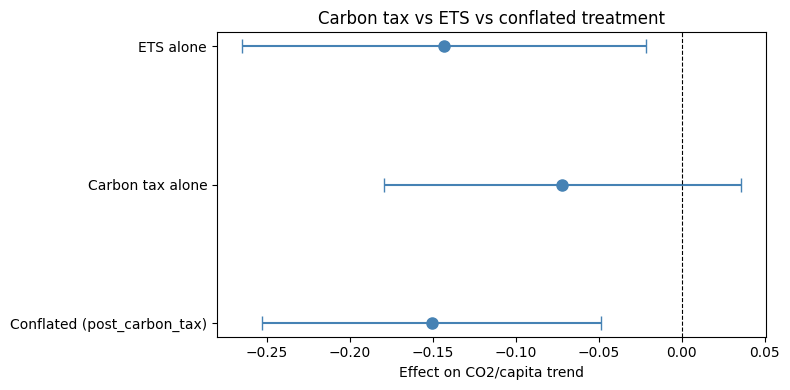

In [3]:
single_df = results[results['spec'].isin(single.keys())]
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(single_df['coef'], range(len(single_df)), xerr=1.96 * single_df['se'],
            fmt='o', color='steelblue', capsize=5, markersize=8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(single_df)))
ax.set_yticklabels(single_df['spec'])
ax.set_xlabel('Effect on CO2/capita trend')
ax.set_title('Carbon tax vs ETS vs conflated treatment')
plt.tight_layout()
plt.savefig('../outputs/tax_vs_ets.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

| Treatment | Effect | p | Reading |
|-----------|--------|---|---------|
| Conflated (`post_carbon_tax`) | -0.151 | 0.004 | Phase 1 headline - tax + ETS pooled |
| Carbon tax alone | -0.072 | 0.19 | not significant |
| ETS alone | -0.143 | 0.02 | significant |
| Both: tax (adj. for ETS) | -0.047 | 0.42 | not significant |
| Both: ETS (adj. for tax) | -0.138 | 0.03 | significant |

**The Phase 1 headline was largely the ETS effect.** Separated cleanly, the EU ETS carries a significant reduction (~-0.14), while the standalone national carbon tax is weaker (~-0.07) and not statistically significant in this sample.

Caveats:
- The tax-only cell is small (94 country-years, 15 heterogeneous countries), so power is low - insignificance is not proof of no effect.
- The ETS estimate is dominated by the 2005 EU wave; year FE absorb common shocks, so identification is the EU-vs-non-EU differential trend (the usual parallel-trends caveat applies).
- With an interaction term, carbon tax alone is significant (-0.093, p=0.02) and the tax x ETS interaction is positive but insignificant (+0.092, p=0.32), hinting at diminishing returns when both are present.

**Next steps:** split `tax_price` into a carbon-tax rate vs ETS allowance price for dose-response, then estimate the 4-cell categorical treatment (none / tax / ETS / both) with `ForestDRLearner`.

## 2. Dose-response: does a higher price buy more reduction?

The binary indicators ignore *how big* the price is. Using the de-conflated `tax_price_only` and `ets_price_only` (clean carbon-tax rate vs ETS allowance price), we estimate a within-FE quadratic dose-response. As in Phase 1, the parametric FE model is the trustworthy estimate; the `CausalForestDML` continuous-treatment version (skill default) is shown afterwards but its level is confounded without country FE.

In [4]:
# Parametric dose-response (country + year FE, clustered SEs)
dose = {}
for price in ['tax_price_only', 'ets_price_only']:
    m_lin = fit(f"{y} ~ {price} {fe}")
    m_quad = fit(f"{y} ~ {price} + I({price}**2) {fe}")
    dose[price] = m_quad
    sq = f'I({price} ** 2)'
    print(f"{price}:")
    print(f"  linear:    {m_lin.params[price]:+.5f} per $/t  (p={m_lin.pvalues[price]:.3f})")
    print(f"  quadratic: {m_quad.params[price]:+.5f} (p={m_quad.pvalues[price]:.3f}), "
          f"sq {m_quad.params[sq]:+.6f} (p={m_quad.pvalues[sq]:.3f})\n")

tax_price_only:
  linear:    -0.00020 per $/t  (p=0.760)
  quadratic: -0.00165 (p=0.233), sq +0.000011 (p=0.093)



ets_price_only:
  linear:    -0.00583 per $/t  (p=0.004)
  quadratic: -0.00918 (p=0.111), sq +0.000110 (p=0.414)



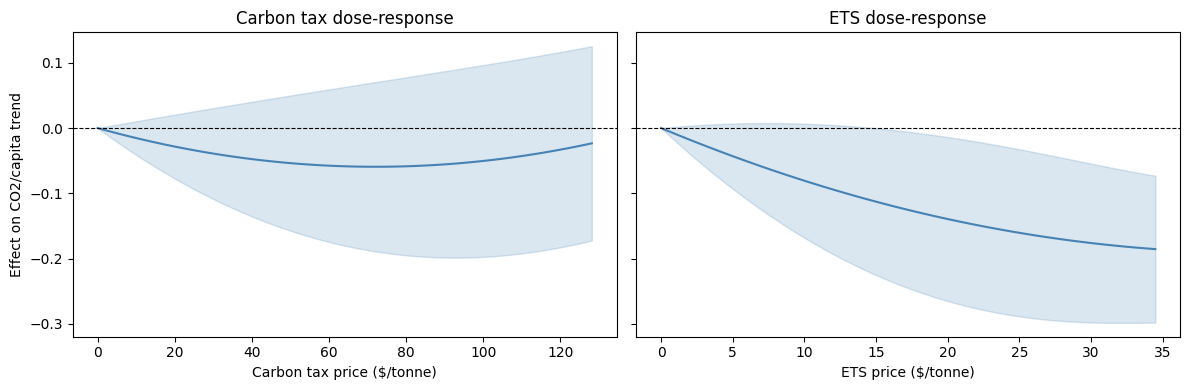

In [5]:
# Dose-response curves with delta-method 95% CI
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, price, title in zip(axes, ['tax_price_only', 'ets_price_only'],
                            ['Carbon tax', 'ETS']):
    m = dose[price]
    sq = f'I({price} ** 2)'
    grid = np.linspace(0, d.loc[d[price] > 0, price].quantile(0.95), 60)
    b1, b2 = m.params[price], m.params[sq]
    cov = m.cov_params()
    eff = b1 * grid + b2 * grid**2
    var = (grid**2 * cov.loc[price, price] + grid**4 * cov.loc[sq, sq]
           + 2 * grid**3 * cov.loc[price, sq])
    se = np.sqrt(var)
    ax.plot(grid, eff, color='steelblue')
    ax.fill_between(grid, eff - 1.96 * se, eff + 1.96 * se, alpha=0.2, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(f'{title} price ($/tonne)')
    ax.set_title(f'{title} dose-response')
axes[0].set_ylabel('Effect on CO2/capita trend')
plt.tight_layout()
plt.savefig('../outputs/dose_response.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Secondary: CausalForestDML continuous-treatment dose-response (skill rule 6).
# Caveat: no country FE -> level confounded (comes out wrong-signed), as in the effects library.
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

W_cf = ['log_gdp', 'log_population', 'natural_resource_rents_per_gdp', 'years_since_tax']
X_cf = ['implementation_capacity_z', 'fossil_pct_filled']
cf = df.dropna(subset=[y, 'tax_price_only']).copy()
for c in W_cf + X_cf:
    cf[c] = cf[c].fillna(cf[c].median())

est = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=30, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, min_samples_leaf=30, random_state=42),
    treatment_featurizer=PolynomialFeatures(degree=2, include_bias=False),
    n_estimators=300, min_samples_leaf=50, max_depth=4, random_state=42)
est.fit(cf[y].values, cf[['tax_price_only']].values, X=cf[X_cf].values, W=cf[W_cf].values)
for p in [10, 30, 80]:
    print(f"forest tax dose $0->${p}: {est.effect(cf[X_cf].values, T0=0, T1=p).mean():+.4f} "
          f"(confounded level - not trusted)")

forest tax dose $0->$10: +0.1104 (confounded level - not trusted)


forest tax dose $0->$30: +0.2723 (confounded level - not trusted)


forest tax dose $0->$80: +0.3324 (confounded level - not trusted)


## Dose-response findings

| Price | Linear effect per $/t | p | Reading |
|-------|----------------------|---|---------|
| Carbon tax (`tax_price_only`) | -0.0002 | 0.76 | flat, not significant |
| ETS (`ets_price_only`) | **-0.0058** | **0.004** | significant, ~linear |

The ETS shows a clear dose-response: each extra $1/tonne of allowance price buys roughly -0.006 of additional reduction (so ~-0.18 at $30). The carbon tax dose-response is flat and insignificant - consistent with the binary result that the standalone tax effect is weak in this sample.

The `CausalForestDML` continuous-treatment version returns positive (wrong-signed) dose-response levels: without country fixed effects the cross-country price variation is confounded (high-price countries differ systematically), exactly the issue documented in `causal_effects_library.ipynb`. We therefore report the parametric within-FE estimate.

**Takeaway so far:** across binary and continuous specifications, the carbon-pricing effect in this data is carried by the **EU ETS**, not standalone national carbon taxes. The tax-only evidence is weak and underpowered (15 countries) - a genuine question for data expansion, not a settled null.